# MCDI500 — Programación para la Ciencia de Datos
## Fase 4: Visualizaciones analíticas y comunicación de resultados

**Proyecto:** PROYECTO-GRUPO4-MCDI500  
**Integrantes:**
- Carolina Cortés Donoso
- Pedro Espinoza Vicentela
- Marcelo Corro Troncoso
- Juan Pablo Valdebenito Loyola

**Docente:** Omar Iván Salinas Silva  
**Fecha:** Junio 2026

# I. Introducción

Esta fase constituye el cierre integrador del proyecto. No incorpora nuevo contenido técnico, sino que consolida, valida y comunica los resultados obtenidos en las fases anteriores.

**Hilo conductor F1–F4:**

| Fase | Foco | Producto principal |
|------|------|--------------------|
| F1 | Definición del problema y entorno | Dataset crudo cargado, pregunta central |
| F2 | Preprocesamiento y transformación | wdbc_procesado.csv, pipeline funcional |
| F3 | Núcleo algorítmico y POO | Algoritmos de búsqueda, clases src/ |
| F4 | Visualizaciones y comunicación | Tres gráficos analíticos, storytelling |

**Pregunta central:**  
*¿Es posible predecir si un tumor mamario es benigno o maligno usando características morfológicas celulares?*

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../../src'))

RUTA_RAW       = '../../data/raw/wdbc.data'
RUTA_PROCESADO = '../../data/processed/wdbc_procesado.csv'

print('Python:', sys.version)
print('NumPy: ', np.__version__)
print('Pandas:', pd.__version__)

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
NumPy:  2.4.6
Pandas: 3.0.3


---
# II. Resumen F1 — Definición del problema y dataset crudo

En la Fase 1 se configuró el entorno reproducible, se identificó el dataset y se formuló la pregunta central del proyecto.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository (Dua & Graff, 2019).  
**Instancias:** 569 registros, 32 columnas (id, diagnóstico y 30 variables morfológicas celulares).  
**Variable objetivo:** diagnostico — B (benigno) / M (maligno).

In [2]:
COLUMNAS = [
    'id', 'diagnostico',
    'radio_mean', 'textura_mean', 'perimetro_mean', 'area_mean',
    'suavidad_mean', 'compacidad_mean', 'concavidad_mean', 'puntos_concavos_mean',
    'simetria_mean', 'dimension_fractal_mean',
    'radio_se', 'textura_se', 'perimetro_se', 'area_se',
    'suavidad_se', 'compacidad_se', 'concavidad_se', 'puntos_concavos_se',
    'simetria_se', 'dimension_fractal_se',
    'radio_worst', 'textura_worst', 'perimetro_worst', 'area_worst',
    'suavidad_worst', 'compacidad_worst', 'concavidad_worst', 'puntos_concavos_worst',
    'simetria_worst', 'dimension_fractal_worst'
]

df_crudo = pd.read_csv(RUTA_RAW, header=None, names=COLUMNAS)

print(f'Forma del dataset crudo: {df_crudo.shape[0]} filas x {df_crudo.shape[1]} columnas')
print(f'Distribucion diagnostico: {df_crudo["diagnostico"].value_counts().to_dict()}')
print(f'Valores NA: {df_crudo.isna().sum().sum()}')
df_crudo.head(3)

Forma del dataset crudo: 569 filas x 32 columnas
Distribucion diagnostico: {'B': 357, 'M': 212}
Valores NA: 0


,id,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


---
# III. Resumen F2 — Preprocesamiento y transformación

En la Fase 2 se construyó el pipeline de limpieza y transformación. En la Fase 3 fue encapsulado en la clase Preprocesador (src/preprocesador.py).

| Paso | Método | Justificación |
|------|--------|---------------|
| Eliminar id | .eliminar_columnas(['id']) | Identificador sin valor predictivo |
| Eliminar duplicados | .eliminar_duplicados() | Integridad del dataset |
| Imputar NA | .imputar_na(estrategia='mediana') | Robustez ante outliers |
| Codificar diagnóstico | .codificar_diagnostico() | B→0, M→1 para análisis numérico |
| Estandarizar | .estandarizar() | StandardScaler: media≈0, std≈1 |
| Validar | .validar() | Assertions automáticas de integridad |

In [3]:
df_proc = pd.read_csv(RUTA_PROCESADO)

print(f'Forma procesada: {df_proc.shape[0]} filas x {df_proc.shape[1]} columnas')
print(f'Valores NA: {df_proc.isna().sum().sum()}')
print(f'Distribucion diagnostico: {df_proc["diagnostico"].value_counts().to_dict()}')
print(f'Media radio_mean (aprox. 0): {df_proc["radio_mean"].mean():.6f}')
print(f'Std  radio_mean (aprox. 1): {df_proc["radio_mean"].std(ddof=0):.6f}')
df_proc.head(3)

Forma procesada: 569 filas x 31 columnas
Valores NA: 0
Distribucion diagnostico: {0: 357, 1: 212}
Media radio_mean (aprox. 0): -0.000000
Std  radio_mean (aprox. 1): 1.000000


,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,simetria_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391


---
# IV. Resumen F3 — Núcleo algorítmico y POO

En la Fase 3 se implementaron algoritmos de búsqueda (O(n) iterativo y O(log n) recursivo) y se introdujo POO mediante clases abstractas y concretas en src/.

| Archivo | Clase(s) | Responsabilidad |
|---------|----------|-----------------|
| src/base.py | Transformador (ABC) | Contrato abstracto aplicar(df) |
| src/preprocesador.py | Preprocesador | Pipeline F2 encapsulado, métodos encadenables |
| src/transformadores.py | EliminadorColumnas, ImputadorNA, CodificadorDiagnostico, EscaladorNumerico | Subclases concretas de Transformador |
| src/pipeline.py | Pipeline | Orquesta transformadores (polimorfismo) |
| src/buscadores.py | BuscadorLineal, BuscadorBinario | Búsqueda O(n) y O(log n) con interfaz común |
| src/algoritmos.py | Funciones | Versión funcional: búsquedas y filtro de correlación |

In [4]:
from algoritmos import busqueda_lineal_iterativa, busqueda_binaria_recursiva, filtro_estructurado_features
from buscadores import BuscadorLineal, BuscadorBinario
from preprocesador import Preprocesador

arreglo = sorted(df_proc['radio_mean'].tolist())
objetivo = arreglo[len(arreglo) // 2]

idx_lineal  = busqueda_lineal_iterativa(arreglo, objetivo)
idx_binaria = busqueda_binaria_recursiva(arreglo, objetivo, 0, len(arreglo) - 1)

print(f'Busqueda lineal  -> indice: {idx_lineal}')
print(f'Busqueda binaria -> indice: {idx_binaria}')
assert idx_lineal == idx_binaria

buscador_poo = BuscadorBinario(df_proc['radio_mean'].tolist())
print(f'BuscadorBinario (POO) -> indice: {buscador_poo.buscar(objetivo)}')

pares = filtro_estructurado_features(df_proc.drop(columns=['diagnostico']), umbral_correlacion=0.8)
print(f'Pares con correlacion > 0.8: {len(pares)}')
print(f'Par de mayor correlacion: {pares[0]}')

Busqueda lineal  -> indice: 284
Busqueda binaria -> indice: 284
BuscadorBinario (POO) -> indice: 284
Pares con correlacion > 0.8: 44
Par de mayor correlacion: ('radio_mean', 'perimetro_mean', 0.9979)


---
# VII.a Preprocesamiento y validación del dataset para visualización

Antes de construir las visualizaciones se verifica que df_proc cumple todas las condiciones necesarias: sin valores faltantes, variable objetivo codificada como entero {0, 1} y variables morfológicas estandarizadas.

El dataset proviene directamente del pipeline de F2 (wdbc_procesado.csv) y no requiere transformaciones adicionales.

In [5]:
assert df_proc.isna().sum().sum() == 0, 'Hay valores NA'
assert set(df_proc['diagnostico'].unique()) == {0, 1}, 'diagnostico debe contener solo 0 y 1'
assert df_proc.shape == (569, 31), f'Forma inesperada: {df_proc.shape}'

vars_morfologicas = [c for c in df_proc.columns if c != 'diagnostico']
n_benigno = (df_proc['diagnostico'] == 0).sum()
n_maligno = (df_proc['diagnostico'] == 1).sum()

print('Dataset validado y listo para visualizacion')
print(f'  Filas             : {df_proc.shape[0]}')
print(f'  Columnas          : {df_proc.shape[1]}')
print(f'  Benignos (0)      : {n_benigno}')
print(f'  Malignos (1)      : {n_maligno}')
print(f'  Variables morfol. : {len(vars_morfologicas)}')
print(f'  Valores NA        : {df_proc.isna().sum().sum()}')
print('Todas las validaciones pasaron correctamente.')

Dataset validado y listo para visualizacion
  Filas             : 569
  Columnas          : 31
  Benignos (0)      : 357
  Malignos (1)      : 212
  Variables morfol. : 30
  Valores NA        : 0
Todas las validaciones pasaron correctamente.


---
# VII.b Gráfico 1 — Distribución de diagnósticos

El primer gráfico da contexto al problema: ¿cuántos casos benignos y malignos tiene el dataset?
Antes de analizar cualquier variable morfológica, es necesario entender la composición del conjunto de datos,
ya que un desbalance severo afecta directamente la interpretación de los resultados.

**Fuente:** Dua & Graff (2019). UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic).

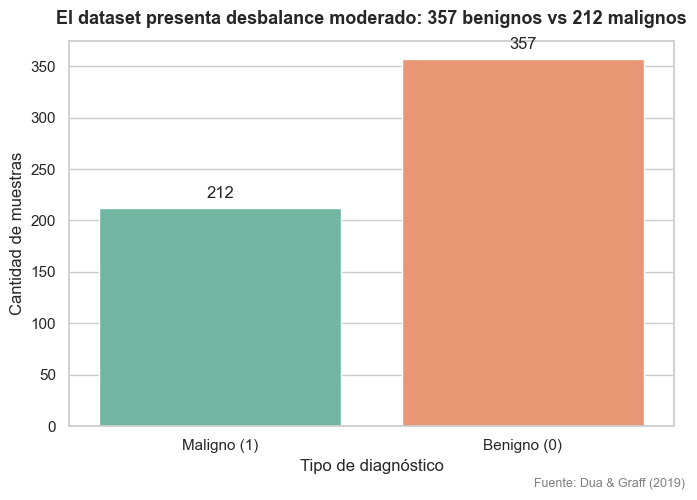

In [6]:
sns.set_theme(style='whitegrid', palette='Set2')

df_proc['Etiqueta_Diagnostico'] = df_proc['diagnostico'].map({1: 'Maligno (1)', 0: 'Benigno (0)'})

fig1, ax1 = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df_proc,
    x='Etiqueta_Diagnostico',
    hue='Etiqueta_Diagnostico',
    dodge=False,
    legend=False,
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12,
        xytext=(0, 5), textcoords='offset points'
    )

ax1.set_title(
    'El dataset presenta desbalance moderado: 357 benignos vs 212 malignos',
    fontsize=13, fontweight='bold', pad=12
)
ax1.set_xlabel('Tipo de diagnóstico', fontsize=12)
ax1.set_ylabel('Cantidad de muestras', fontsize=12)
fig1.text(0.99, 0.01, 'Fuente: Dua & Graff (2019)', ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Interpretación:** El dataset cuenta con 357 casos benignos (62.7%) y 212 malignos (37.3%). El desbalance existe, pero es moderado: no compromete el análisis ni requiere técnicas de balanceo para exploración visual. Lo relevante es tenerlo presente al interpretar los gráficos siguientes, ya que una variable que separa bien los grupos a pesar del desbalance tiene mayor valor predictivo.

---
# VII.c Gráfico 2 — Radio celular medio por diagnóstico

Una vez establecido el contexto, el siguiente paso es verificar si alguna variable morfológica
por sí sola logra separar los grupos. Se escoge `radio_mean` porque es la característica más
directamente relacionada con el tamaño del tumor, y porque el filtro de correlación de F3
identificó que concentra alta correlación con otras variables de área y perímetro.

**Fuente:** Dua & Graff (2019). UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic).

C:\Users\hellb\AppData\Local\Temp\ipykernel_24324\415937188.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='Diagnóstico', loc='upper left')


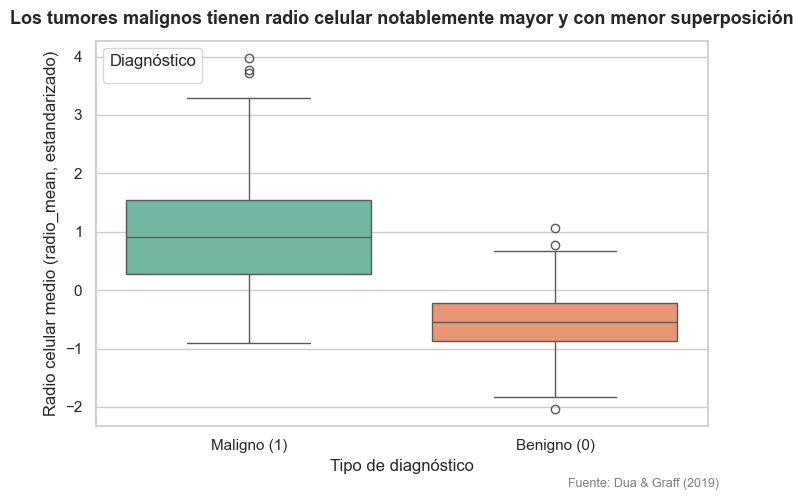

In [7]:
fig2, ax2 = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_proc,
    x='Etiqueta_Diagnostico',
    y='radio_mean',
    hue='Etiqueta_Diagnostico',
    dodge=False,
    ax=ax2
)

ax2.set_title(
    'Los tumores malignos tienen radio celular notablemente mayor y con menor superposición',
    fontsize=13, fontweight='bold', pad=12
)
ax2.set_xlabel('Tipo de diagnóstico', fontsize=12)
ax2.set_ylabel('Radio celular medio (radio_mean, estandarizado)', fontsize=12)
ax2.legend(title='Diagnóstico', loc='upper left')
fig2.text(0.99, 0.01, 'Fuente: Dua & Graff (2019)', ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Interpretación:** Los tumores malignos presentan un radio celular medio significativamente mayor que los benignos. Las cajas tienen poca superposición, lo que indica que esta variable sola ya tiene poder discriminativo. Esto responde parcialmente la pregunta central del proyecto: las características morfológicas no solo son descriptivas, sino que permiten distinguir entre tumores benignos y malignos con cierto grado de confianza. Los valores están estandarizados (media≈0, std≈1), por lo que la escala refleja desviaciones respecto al promedio del dataset.

---
# VII.d Gráfico 3 — Correlación entre variables morfológicas

El tercer gráfico cierra la historia: si una sola variable ya separa los grupos,
¿qué pasa con las 30 en conjunto? El heatmap muestra si las variables son independientes
entre sí o si comparten información. Esto conecta directamente con `filtro_estructurado_features`
de F3, que encontró numerosos pares con correlación superior a 0.8.

**Fuente:** Dua & Graff (2019). UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic).

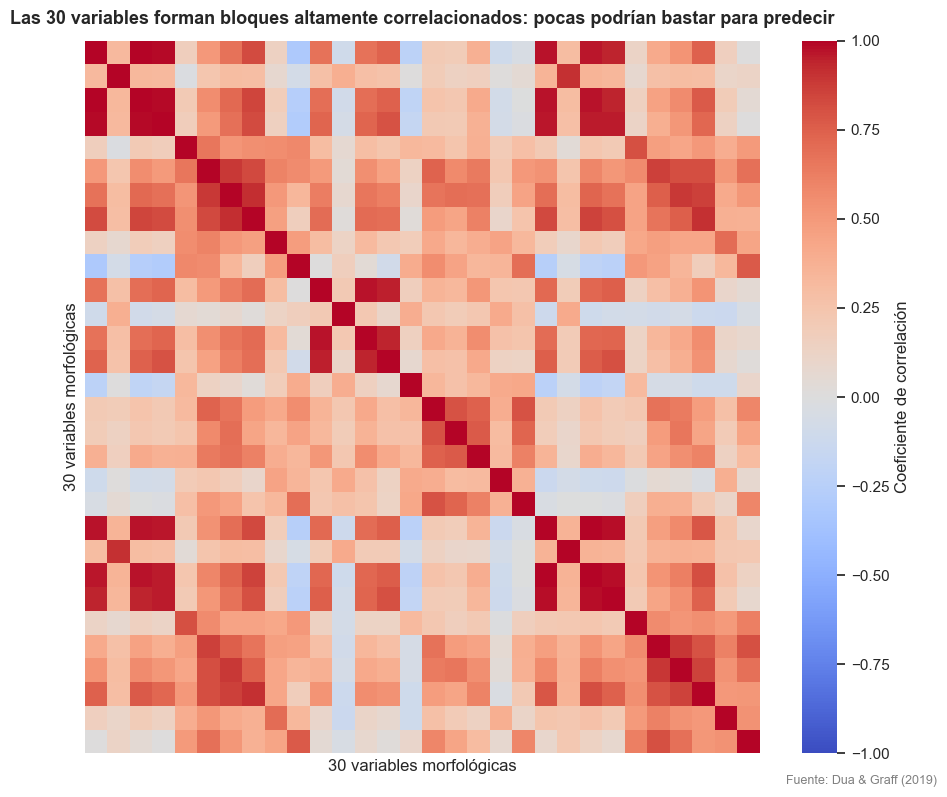

In [8]:
vars_morfologicas = [c for c in df_proc.columns if c not in ('diagnostico', 'Etiqueta_Diagnostico')]
corr_matrix = df_proc[vars_morfologicas].corr()

fig3, ax3 = plt.subplots(figsize=(9, 8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    xticklabels=False, yticklabels=False,
    ax=ax3,
    cbar_kws={'label': 'Coeficiente de correlación'}
)

ax3.set_title(
    'Las 30 variables forman bloques altamente correlacionados: pocas podrían bastar para predecir',
    fontsize=13, fontweight='bold', pad=12
)
ax3.set_xlabel('30 variables morfológicas', fontsize=12)
ax3.set_ylabel('30 variables morfológicas', fontsize=12)
fig3.text(0.99, 0.01, 'Fuente: Dua & Graff (2019)', ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Interpretación:** El heatmap revela bloques de alta correlación entre las variables morfológicas: radio, perímetro y área se mueven juntas, al igual que los grupos `_se` (error estándar) y `_worst` (peor valor). Esto confirma lo que el filtro de F3 ya detectó programáticamente: hay redundancia importante en el dataset. En términos prácticos, un modelo predictivo no necesitaría las 30 variables para funcionar bien; un subconjunto reducido podría capturar la mayor parte de la información disponible. Esta redundancia es una limitación del dataset, pero también una oportunidad para simplificar futuros modelos.